<a href="https://colab.research.google.com/github/NgoHoangNhatMinh/cs3264-project/blob/main/Minh/notebooks/colab_scam_guard_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Util

In [1]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [2]:
!nvidia-smi

Sun Apr 12 12:04:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data preprocessing

In [3]:
from datasets import load_dataset

def load_scam_data():
    print("Downloading/Loading SMS Spam dataset...")
    # This automatically fetches the dataset from Hugging Face
    dataset = load_dataset("sms_spam")

    # The dataset comes pre-split into a 'train' set.
    # Let's look at the structure of the first message:
    print("\nSample Data Structure:")
    print(dataset['train'][0])

    return dataset

dataset = load_scam_data()

Downloading/Loading SMS Spam dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]


Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}


### Tokenize and build vocabulary

In [4]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    # This handles truncation and padding automatically
    return tokenizer(examples["sms"], truncation=True, padding="max_length", max_length=128)

# Map the tokenizer over your existing Hugging Face dataset
tokenized_sms = dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [5]:
print(tokenized_sms["train"].features)

{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## Core model

In [6]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2 # Ham vs Scam
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [7]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5, # Transformers need very small learning rates
    per_device_train_batch_size=16,
    num_train_epochs=10, # Transformers converge very fast
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

split_datasets = tokenized_sms["train"].train_test_split(test_size=0.2, seed=42)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=split_datasets["train"],
    eval_dataset=split_datasets["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.045989,0.988341
2,0.060569,0.051401,0.991928
3,0.060569,0.047663,0.991928
4,0.008428,0.083492,0.987444
5,0.008428,0.069795,0.991928
6,0.002920,0.064350,0.992825
7,0.002920,0.067789,0.991928
8,0.000107,0.069859,0.991928
9,0.000075,0.070652,0.991928
10,0.000075,0.071001,0.991928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2790, training_loss=0.012928010156131133, metrics={'train_runtime': 642.5035, 'train_samples_per_second': 69.4, 'train_steps_per_second': 4.342, 'total_flos': 1476680326517760.0, 'train_loss': 0.012928010156131133, 'epoch': 10.0})

### Saving the Trained Model


In [10]:
import os

save_directory = "./saved_model"

os.makedirs(save_directory, exist_ok=True)

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./saved_model


### Saving to Google Drive

To save your model to Google Drive, you first need to mount your Google Drive to your Colab environment. Then, you can save the model to a specified path within your mounted Drive.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

gdrive_save_directory = "/content/drive/MyDrive/my_colab_models/spam_detector_transformer"

os.makedirs(gdrive_save_directory, exist_ok=True)

model.save_pretrained(gdrive_save_directory)
tokenizer.save_pretrained(gdrive_save_directory)

print(f"Model and tokenizer saved to Google Drive at {gdrive_save_directory}")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to Google Drive at /content/drive/MyDrive/my_colab_models/spam_detector_transformer


## Evaluation

In [8]:
for log in trainer.state.log_history:
    print(log)

metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.04598940163850784, 'eval_accuracy': 0.9883408071748879, 'eval_runtime': 3.9057, 'eval_samples_per_second': 285.48, 'eval_steps_per_second': 35.845, 'epoch': 1.0, 'step': 279}
{'loss': 0.060569137573242185, 'grad_norm': 0.053827088326215744, 'learning_rate': 1.642293906810036e-05, 'epoch': 1.7921146953405018, 'step': 500}
{'eval_loss': 0.05140130966901779, 'eval_accuracy': 0.9919282511210762, 'eval_runtime': 4.4454, 'eval_samples_per_second': 250.822, 'eval_steps_per_second': 31.493, 'epoch': 2.0, 'step': 558}
{'eval_loss': 0.04766322299838066, 'eval_accuracy': 0.9919282511210762, 'eval_runtime': 4.3852, 'eval_samples_per_second': 254.266, 'eval_steps_per_second': 31.926, 'epoch': 3.0, 'step': 837}
{'loss': 0.008427885055541992, 'grad_norm': 0.006343364715576172, 'learning_rate': 1.2838709677419356e-05, 'epoch': 3.5842293906810037, 'step': 1000}
{'eval_loss': 0.08349185436964035, 'eval_accuracy': 0.9874439461883409, 'eval_runtime': 4.4074, 'eval_samples_per_second': 252.

{'eval_loss': 0.04598194360733032, 'eval_accuracy': 0.9883408071748879, 'eval_runtime': 4.2603, 'eval_samples_per_second': 261.722, 'eval_steps_per_second': 32.862, 'epoch': 10.0}


## Statistics Visualization

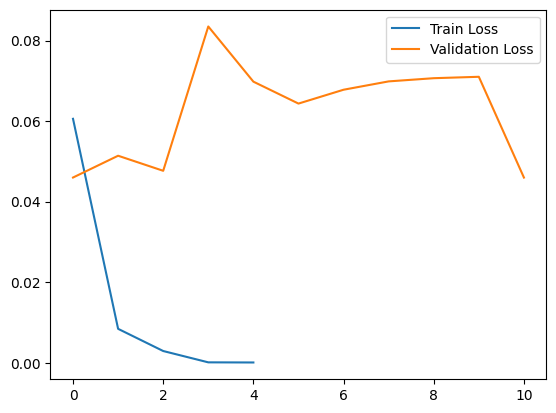

In [9]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.show()

Generating predictions on the test set...



Calculating evaluation metrics...
Accuracy: 0.9883
Precision: 0.9883
Recall: 0.9883
F1-Score: 0.9883

Detailed Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.94      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115


Measuring inference time...
Average inference time per sample: 0.003547 seconds

Generating visualizations...


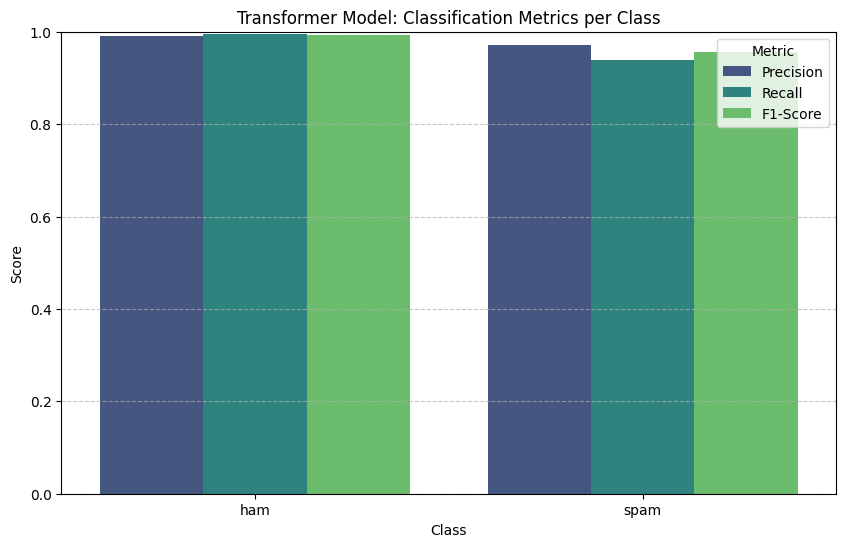

/tmp/ipykernel_22236/3194694298.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(overall_metrics.keys()), y=list(overall_metrics.values()), palette='coolwarm')


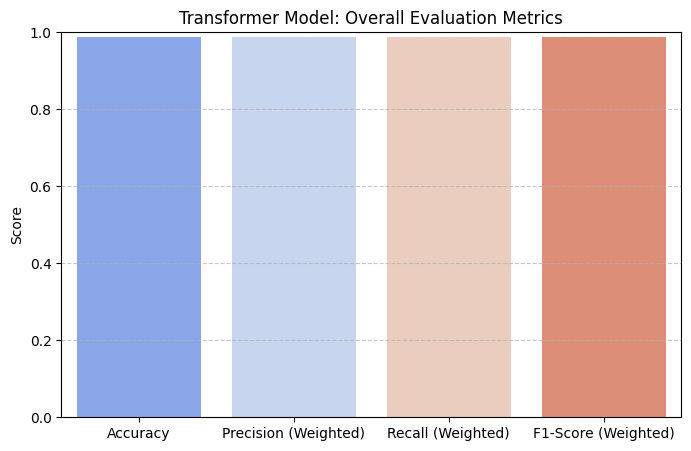

/tmp/ipykernel_22236/3194694298.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Inference Time'], y=[inference_time_per_sample], palette='magma')


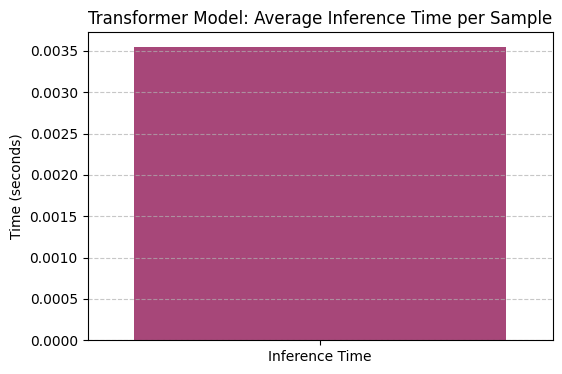

Statistics and visualizations generated successfully!


In [12]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# --- 1. Get predictions from the model on the test set ---
print("Generating predictions on the test set...")
predictions_output = trainer.predict(split_datasets["test"])
predictions = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# --- 2. Calculate Evaluation Metrics ---
print("\nCalculating evaluation metrics...")
accuracy = accuracy_score(labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(labels, predictions, target_names=split_datasets["test"].features["label"].names))

# --- 3. Measure Inference Time ---
print("\nMeasuring inference time...")
sample_size = 100
if len(split_datasets["test"]) < sample_size:
    sample_size = len(split_datasets["test"])

sample_inputs = split_datasets["test"].select(range(sample_size))

start_time = time.time()
import torch

sample_input_ids = torch.tensor(sample_inputs['input_ids']).to(model.device)
sample_attention_mask = torch.tensor(sample_inputs['attention_mask']).to(model.device)

with torch.no_grad():
    model.eval()
    _ = model(input_ids=sample_input_ids, attention_mask=sample_attention_mask)
end_time = time.time()

inference_time_per_sample = (end_time - start_time) / sample_size
print(f"Average inference time per sample: {inference_time_per_sample:.6f} seconds")

# --- 4. Visualizations ---
print("\nGenerating visualizations...")

# Plotting Classification Metrics (Precision, Recall, F1-Score per class)
report_dict = classification_report(labels, predictions, target_names=split_datasets["test"].features["label"].names, output_dict=True)

metrics_df = {} # To store precision, recall, f1 for plotting
for label_name in split_datasets["test"].features["label"].names:
    if label_name in report_dict:
        metrics_df[label_name] = {
            'Precision': report_dict[label_name]['precision'],
            'Recall': report_dict[label_name]['recall'],
            'F1-Score': report_dict[label_name]['f1-score']
        }

# Convert to DataFrame for easy plotting
import pandas as pd
metrics_df = pd.DataFrame(metrics_df).T

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df.reset_index().melt(id_vars='index'), x='index', y='value', hue='variable', palette='viridis')
plt.title('Transformer Model: Classification Metrics per Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Overall Metrics Bar Plot
overall_metrics = {
    'Accuracy': accuracy,
    'Precision (Weighted)': precision,
    'Recall (Weighted)': recall,
    'F1-Score (Weighted)': f1
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(overall_metrics.keys()), y=list(overall_metrics.values()), palette='coolwarm')
plt.title('Transformer Model: Overall Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Inference Time Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=['Inference Time'], y=[inference_time_per_sample], palette='magma')
plt.title('Transformer Model: Average Inference Time per Sample')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Statistics and visualizations generated successfully!")